# Notebook 06 — Feature Engineering
Build feature matrix, inspect NaN%, correlations, and save to parquet.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_config, set_seed, ensure_dirs
from src.data_loader import load_all
from src.features.pipeline import build_feature_matrix

cfg = load_config('../config.yaml')
cfg['paths']['dataset'] = '../dataset'
cfg['paths']['outputs'] = '../outputs'
cfg['paths']['figures'] = '../outputs/figures'
cfg['paths']['models']  = '../outputs/models'
cfg['paths']['cv_results'] = '../outputs/cv_results'
cfg['paths']['submissions'] = '../outputs/submissions'
cfg['paths']['report_figures'] = '../report/figures'

set_seed(cfg['seed'])
ensure_dirs(cfg)
print('Config loaded. Dataset path:', cfg['paths']['dataset'])

Config loaded. Dataset path: ../dataset


In [2]:
print('Loading all tables...')
tables = load_all(cfg)
print(f"Tables loaded: {list(tables.keys())}")

[10:11:59] INFO data_loader: Loading all datasets...


Loading all tables...


[10:12:01] INFO data_loader:   sales: 3,833 rows x 3 cols
[10:12:01] INFO data_loader:   submission: 548 rows x 3 cols
[10:12:01] INFO data_loader:   products: 2,412 rows x 8 cols
[10:12:01] INFO data_loader:   customers: 121,930 rows x 7 cols
[10:12:01] INFO data_loader:   geography: 39,948 rows x 4 cols
[10:12:01] INFO data_loader:   promotions: 50 rows x 10 cols
[10:12:01] INFO data_loader:   orders: 646,945 rows x 8 cols
[10:12:01] INFO data_loader:   order_items: 714,669 rows x 7 cols
[10:12:01] INFO data_loader:   payments: 646,945 rows x 4 cols
[10:12:01] INFO data_loader:   shipments: 566,067 rows x 4 cols
[10:12:01] INFO data_loader:   returns: 39,939 rows x 7 cols
[10:12:01] INFO data_loader:   reviews: 113,551 rows x 7 cols
[10:12:01] INFO data_loader:   inventory: 60,247 rows x 17 cols
[10:12:01] INFO data_loader:   web_traffic: 3,652 rows x 7 cols


Tables loaded: ['sales', 'submission', 'products', 'customers', 'geography', 'promotions', 'orders', 'order_items', 'payments', 'shipments', 'returns', 'reviews', 'inventory', 'web_traffic']


In [3]:
FEAT_PATH = '../outputs/feature_matrix.parquet'

print('Building feature matrix...')
df = build_feature_matrix(cfg, tables, save_path=FEAT_PATH)

print(f'\nFeature matrix shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'\nDtypes summary:')
print(df.dtypes.value_counts())

[10:12:01] INFO feature_pipeline: Base df: 4381 rows (2012-07-04 to 2024-07-01)
[10:12:01] INFO feature_pipeline: Adding lag features...
[10:12:01] INFO feature_pipeline: Adding calendar features...


Building feature matrix...


[10:12:02] INFO feature_pipeline: Building transactional aggregates...
[10:12:03] INFO feature_pipeline: Joining transactional features (lag 1)...
[10:12:03] INFO feature_pipeline: Joining inventory features...
[10:12:03] INFO feature_pipeline: Building promotion features...
[10:12:05] INFO feature_pipeline: Adding derived features...
[10:12:05] INFO feature_pipeline: Feature matrix shape: (4381, 220)
[10:12:05] INFO feature_pipeline: Saved feature matrix to ../outputs/feature_matrix.parquet



Feature matrix shape: (4381, 220)
Date range: 2012-07-04 to 2024-07-01

Dtypes summary:
float64           185
int32              22
int64              12
datetime64[ns]      1
Name: count, dtype: int64


In [4]:
# NaN analysis
nan_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nan_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': nan_pct
})
nan_report = nan_report[nan_report['Missing Count'] > 0]
print(f'Columns with NaN: {len(nan_report)} / {df.shape[1]}')
print('\nTop 20 columns by NaN%:')
display(nan_report.head(20).style.format({'Missing %': '{:.1f}%'}))

Columns with NaN: 146 / 220

Top 20 columns by NaN%:


,Missing Count,Missing %
COGS,548,12.5%
COGS_ewm14,1,0.0%
COGS_ewm30,1,0.0%
COGS_ewm7,1,0.0%
COGS_ewm90,1,0.0%
COGS_lag1,548,12.5%
COGS_lag14,548,12.5%
COGS_lag180,548,12.5%
COGS_lag2,548,12.5%
COGS_lag21,548,12.5%


In [5]:
# Correlation with Revenue (train rows only)
train_df = df[df['Revenue'].notna()].copy()
numeric_cols = [c for c in train_df.columns
                if train_df[c].dtype != object and c not in ['Revenue', 'COGS']]

corr_rev = (
    train_df[numeric_cols]
    .corrwith(train_df['Revenue'])
    .dropna()
    .abs()
    .sort_values(ascending=False)
)

top30 = corr_rev.head(30)
print('Top 30 features by |correlation| with Revenue:')
display(pd.DataFrame({'|Corr with Revenue|': top30}).style.format('{:.4f}'))

Top 30 features by |correlation| with Revenue:


,|Corr with Revenue|
Revenue_lag1,0.8655
total_payment,0.8612
COGS_lag1,0.8365
COGS_same_week_ly,0.8261
n_customers,0.8197
n_orders,0.8186
COGS_lag365,0.8064
Revenue_same_week_ly,0.8061
n_order_lines,0.7983
n_items,0.7972


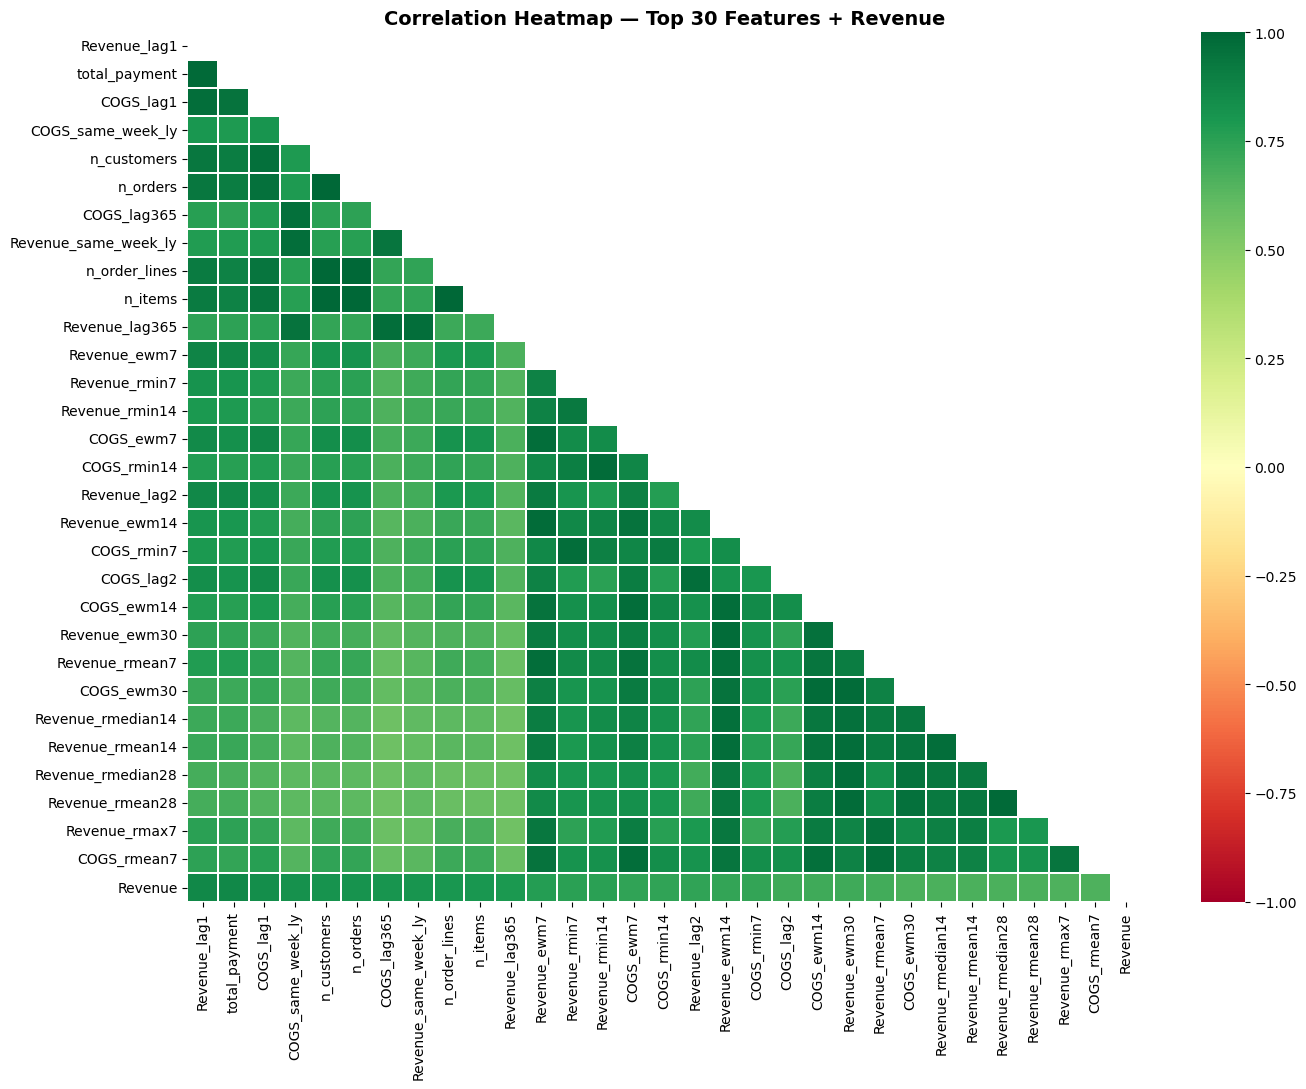

Saved: ../outputs/figures/06_feature_corr_heatmap.png


In [6]:
# Heatmap: top 30 features + Revenue
top30_cols = list(top30.index[:30]) + ['Revenue']
corr_matrix = train_df[top30_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Correlation Heatmap — Top 30 Features + Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = cfg['paths']['figures'] + '/06_feature_corr_heatmap.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

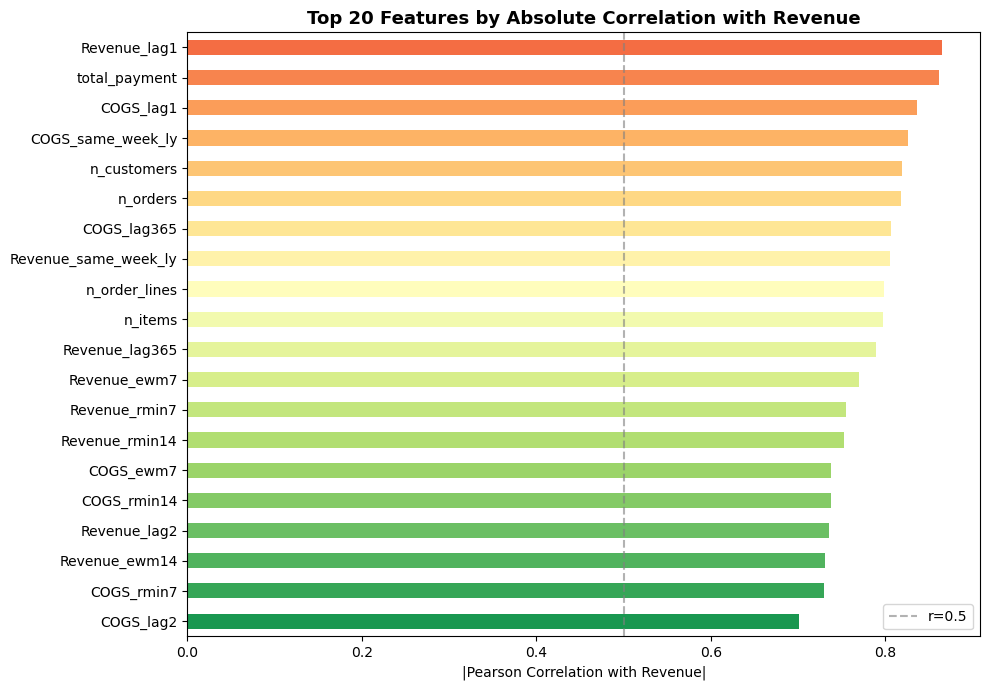

Saved: ../outputs/figures/06_top20_feature_corr.png

Feature matrix saved to: ../outputs/feature_matrix.parquet
Shape: (4381, 220)
Feature engineering complete.


In [7]:
# Bar chart: top 20 feature correlations
fig, ax = plt.subplots(figsize=(10, 7))
top20 = corr_rev.head(20)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top20)))
top20[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_xlabel('|Pearson Correlation with Revenue|')
ax.set_title('Top 20 Features by Absolute Correlation with Revenue', fontsize=13, fontweight='bold')
ax.axvline(0.5, ls='--', color='gray', alpha=0.6, label='r=0.5')
ax.legend()
plt.tight_layout()

fig2_path = cfg['paths']['figures'] + '/06_top20_feature_corr.png'
fig.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path}')

print(f'\nFeature matrix saved to: {FEAT_PATH}')
print(f'Shape: {df.shape}')
print('Feature engineering complete.')